# Exploración del dataset con RAPIDS (cuDF / CuPy)

La transformación de la clase ternaria se ejecuta de forma vectorizada en GPU. `cuML` no se importa porque esta notebook todavía no entrena modelos.

## Librerías

In [1]:
import os
import cudf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())

cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria


## URLs y constantes

In [3]:
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')
DATA_URL = os.path.join(DATA_FOLDER, 'competencia_01_crudo.csv')


## Lectura de datos en GPU

## Diccionario de datos

In [4]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

In [5]:
data_dict = pd.read_excel(os.path.join(DATA_FOLDER, 'DiccionarioDatos_2026.ods'), engine='odf')

In [ ]:
# guardamos en csv
# data_dict.to_csv(os.path.join(DATA_FOLDER, 'data_dict.csv'))

# data_dict

## Dataset

In [7]:
# df = cudf.read_csv(
#     DATA_URL,
#     dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
# )
df = pd.read_csv(
    DATA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [8]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,0.0,1.0,0.0,-16247.77,0.0,4056.0,15732.34,1.0,0.0,1137.81
1,12159858,202103,1,0,0,48,102,78.43,24418.75,-73.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12160484,202103,1,0,0,60,55,8101.55,3162.23,13399.50,...,0.0,1.0,0.0,-31103.23,0.0,1632.0,2860.54,2.0,0.0,19858.89
3,12160591,202103,1,0,0,46,275,14825.78,138050.05,1146.27,...,0.0,1.0,0.0,-13733.44,0.0,2122.0,1419.36,3.0,0.0,1231.65
4,12160747,202103,1,0,0,47,194,2015.61,31240.49,1791.25,...,0.0,1.0,0.0,0.00,0.0,5901.0,1286.93,1.0,0.0,82.11


In [9]:
df.describe()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
count,9.830610e+05,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,983061.000000,9.830610e+05,983061.000000,...,855301.000000,935525.000000,9.358750e+05,8.553010e+05,855301.000000,935875.000000,8.553010e+05,855301.000000,855301.000000,9.358750e+05
mean,3.779833e+07,202105.506242,0.986954,0.003166,0.049117,46.884686,134.912766,2445.401757,2.484136e+04,1614.815041,...,0.026915,5.699941,6.631840e+03,-4.040167e+04,7.407502,3245.136853,2.342605e+04,8.171195,0.008112,6.828315e+03
std,1.586785e+07,1.707532,0.113472,0.056175,0.271282,12.987574,86.282920,8267.171556,6.822922e+04,3122.676446,...,4.733806,8.690398,2.824518e+04,5.785297e+04,113.542213,2246.969985,4.595059e+04,10.037463,0.192377,2.686818e+04
min,1.215985e+07,202103.000000,0.000000,0.000000,0.000000,18.000000,1.000000,-271488.390000,-9.380887e+05,-52407.900000,...,0.000000,0.000000,0.000000e+00,-3.280279e+06,0.000000,1.000000,-4.593328e+05,0.000000,0.000000,0.000000e+00
25%,2.549570e+07,202104.000000,1.000000,0.000000,0.000000,37.000000,63.000000,71.110000,1.884690e+03,366.730000,...,0.000000,2.000000,0.000000e+00,-4.927173e+04,0.000000,1424.000000,2.328830e+03,2.000000,0.000000,6.686100e+02
50%,3.596115e+07,202106.000000,1.000000,0.000000,0.000000,45.000000,128.000000,1416.530000,1.334347e+04,981.750000,...,0.000000,5.000000,0.000000e+00,-2.446880e+04,0.000000,2943.000000,1.024627e+04,5.000000,0.000000,2.463300e+03
75%,4.905971e+07,202107.000000,1.000000,0.000000,0.000000,56.000000,190.000000,3304.210000,3.206790e+04,2181.850000,...,0.000000,7.000000,0.000000e+00,-1.072019e+04,0.000000,4841.000000,2.776373e+04,11.000000,0.000000,6.146520e+03
max,7.825496e+07,202108.000000,1.000000,1.000000,4.000000,101.000000,380.000000,784129.030000,7.023011e+06,513155.480000,...,2062.110000,3443.000000,2.533917e+06,7.694699e+05,17196.390000,12751.000000,9.220294e+06,240.000000,19.000000,1.141511e+07


In [10]:
# nas = df.isna().sum()
# nas[nas > 0]

## Columnas

In [11]:
# for column in df.columns:
#     print(column)

## Clientes individuales

In [12]:
df['numero_de_cliente'].max()

np.int32(78254956)

In [13]:
n_clientes = df['numero_de_cliente'].nunique()
print(f'tenemos {n_clientes} clientes individuales en {len(df)} registros')
# df['numero_de_cliente'].value_counts()

tenemos 169727 clientes individuales en 983061 registros


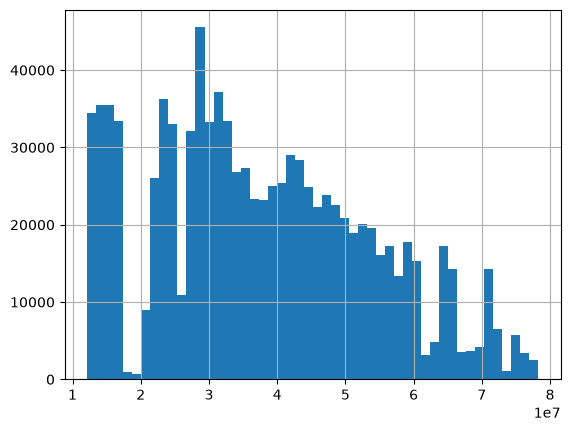

In [14]:
# Matplotlib trabaja en CPU: se transfiere únicamente esta serie para graficar.
# df['numero_de_cliente'].to_pandas().hist(bins=50)
df['numero_de_cliente'].hist(bins=50)
plt.show()

In [15]:
# df.groupby('numero_de_cliente').sum()

## Control de cliente-mes

Se valida directamente sobre pares `(numero_de_cliente, foto_mes)`, sin crear listas Python por cliente.

In [16]:
ordenado = df[['numero_de_cliente', 'foto_mes']].sort_values(
    ['numero_de_cliente', 'foto_mes']
)

duplicados = ordenado.duplicated(['numero_de_cliente', 'foto_mes']).sum()

# Índice mensual consecutivo: funciona también entre diciembre y enero.
year = ordenado['foto_mes'] // 100
month = ordenado['foto_mes'] % 100
ordenado['mes_idx'] = year * 12 + month
ordenado['salto'] = ordenado.groupby('numero_de_cliente')['mes_idx'].diff()

gaps = (ordenado['salto'] > 1).sum()
print('Pares cliente-mes duplicados:', int(duplicados))
print('Gaps mensuales:', int(gaps))

Pares cliente-mes duplicados: 0
Gaps mensuales: 23


# Clase ternaria


In [17]:
df = ternaria(df)

/home/marco/code/DMEyF/dmeyf2026/funciones/ternaria.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['mes_idx'] = year * 12 + month
/home/marco/code/DMEyF/dmeyf2026/funciones/ternaria.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ternaria'] = pd.Series(None, index=df.index, dtype='str')


In [18]:
df['ternaria'].value_counts(dropna=False)

ternaria
continua    645999
NaN         327892
BAJA+1        5103
BAJA+2        4067
Name: count, dtype: int64

In [19]:
# cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])
pd.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


### Guardamos el CSV con clase ternaria.


In [ ]:
# df.to_csv(os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv'))

# Analisis de los clientes q se dan de baja 
    es irrelevante si es baja + 1 o baja +2, todo baja mas 1 es baja+2 mirando desde un mes antes

In [24]:
mask_baja = (df['ternaria'] == 'baja+1' )|(df['ternaria'] == 'baja+2')
df.loc[ mask_baja]

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo,ternaria,mes_baja
124,12188338,202103,1,0,2,64,316,4120.65,40495.90,344.01,...,0.0,-7005.82,0.0,8351.0,10781.85,8.0,0.0,52831.92,baja+2,202105
183,12200827,202103,1,0,0,63,278,383.60,7623.06,71.20,...,0.0,-8726.68,0.0,3520.0,6402.21,2.0,0.0,2557.14,baja+2,202105
249,12218654,202103,1,0,0,55,375,91.07,5334.66,99.49,...,0.0,NaN,NaN,8200.0,NaN,NaN,NaN,0.00,baja+1,202104
288,12227617,202103,1,0,1,46,118,1598.48,6822.74,1676.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baja+2,202105
615,12305745,202103,1,0,0,53,292,126.93,287.85,64.44,...,0.0,-3429.98,0.0,7827.0,3588.47,2.0,0.0,140.76,baja+2,202105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818040,77515244,202107,1,0,0,27,5,1.92,8.59,0.00,...,0.0,NaN,NaN,123.0,NaN,NaN,NaN,0.00,baja+1,202108
818111,77582551,202107,1,0,1,56,4,-8.36,-8.36,13.53,...,0.0,0.00,0.0,103.0,580.61,1.0,0.0,175.95,baja+1,202108
818208,77733822,202107,0,0,0,25,3,0.00,0.00,0.00,...,0.0,NaN,NaN,72.0,NaN,NaN,NaN,0.00,baja+1,202108
818403,78074138,202107,0,0,0,43,1,0.00,0.00,0.00,...,0.0,NaN,NaN,11.0,NaN,NaN,NaN,0.00,baja+1,202108


## Consolidamos columnas para primer analisis

### AGregamos mes de baja

In [25]:
import pandas as pd

def agregar_mes_baja(
    df,
    cliente_col="numero_de_cliente",
    mes_col="foto_mes"
):
    resultado = df.copy()

    ultimo_mes_dataset = resultado[mes_col].max()

    ultimo_mes_cliente = (
        resultado
        .groupby(cliente_col)[mes_col]
        .max()
    )

    mes_baja = pd.Series(
        pd.NA,
        index=ultimo_mes_cliente.index,
        dtype="Int64"
    )

    clientes_baja = ultimo_mes_cliente < ultimo_mes_dataset
    ultimo_mes = ultimo_mes_cliente.loc[clientes_baja]

    # Calcula correctamente el mes siguiente, incluyendo diciembre → enero
    mes_baja.loc[clientes_baja] = (
        (ultimo_mes // 100 + (ultimo_mes % 100 == 12)) * 100
        + (ultimo_mes % 100) % 12 + 1
    ).astype("Int64")

    resultado["mes_baja"] = (
        resultado[cliente_col]
        .map(mes_baja)
        .astype("Int64")
    )

    return resultado

In [26]:
df = agregar_mes_baja(df)

### Consolidamos info

In [59]:
def agregar_variables_perfil(df):

    columnas_base = [
        "numero_de_cliente",
        "foto_mes",
        "mes_baja",
        "active_quarter",
        "cliente_vip",

        # Actividad general y digital
        "ctrx_quarter",
        "chomebanking_transacciones",
        "cmobile_app_trx",

        # Transferencias
        "mtransferencias_recibidas",
        "mtransferencias_emitidas",

        # Pagos habituales
        "mpagodeservicios",
        "mpagomiscuentas",
        "mcuenta_debitos_automaticos",

        # Extracciones
        "mextraccion_autoservicio",

        # Mantenimiento, saldo y productos
        "mcomisiones_mantenimiento",
        "mcuentas_saldo",
        "cproductos"
    ]

    resultado = df[columnas_base].copy()

    # Consumo con débito + Visa + Mastercard
    resultado["mtarjetas_consumo"] = df[
        [
            "mautoservicio",
            "mtarjeta_visa_consumo",
            "mtarjeta_master_consumo"
        ]
    ].sum(axis=1, min_count=1)

    # Total pagado en Visa + Mastercard
    resultado["mtarjetas_pagado"] = df[
        [
            "Visa_mpagado",
            "Master_mpagado"
        ]
    ].sum(axis=1, min_count=1)

    # Total acreditado como sueldo
    resultado["msueldo_acreditado"] = df[
        [
            "mpayroll",
            "mpayroll2"
        ]
    ].sum(axis=1, min_count=1)

    return resultado

In [60]:
df_resumen = agregar_variables_perfil(df)

In [74]:
df_resumen

,numero_de_cliente,foto_mes,mes_baja,active_quarter,cliente_vip,ctrx_quarter,chomebanking_transacciones,cmobile_app_trx,mtransferencias_recibidas,mtransferencias_emitidas,mpagodeservicios,mpagomiscuentas,mcuenta_debitos_automaticos,mextraccion_autoservicio,mcomisiones_mantenimiento,mcuentas_saldo,cproductos,mtarjetas_consumo,mtarjetas_pagado,msueldo_acreditado
0,12159854,202103,<NA>,1,0,64,0,1,28365.53,0.0,0.0,0.00,70.39,45747.0,0.00,24675.22,10,35884.48,0.00,98352.15
1,12159858,202103,<NA>,1,0,65,24,1,47621.55,0.0,0.0,5744.48,70.39,7038.0,0.00,41.62,5,5176.28,NaN,51304.77
2,12160484,202103,<NA>,1,0,65,53,1,26392.50,0.0,0.0,0.00,0.00,22287.0,1622.81,2635.47,7,36136.28,0.00,0.00
3,12160591,202103,<NA>,1,0,64,5,1,105393.78,0.0,0.0,2930.17,11910.38,0.0,0.00,314336.17,10,33707.30,0.00,105393.78
4,12160747,202103,<NA>,1,0,62,48,1,11730.00,13841.4,0.0,4941.76,0.00,0.0,1774.04,18253.96,7,6330.83,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983056,78249586,202108,<NA>,0,0,2,6,0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,6,0.00,0.00,0.00
983057,78249850,202108,<NA>,1,0,6,13,1,2932.50,0.0,0.0,0.00,0.00,0.0,0.00,1055.70,7,8140.50,340.17,0.00
983058,78250419,202108,<NA>,1,0,14,59,1,46165.52,0.0,0.0,0.00,0.00,45747.0,0.00,-264.67,6,0.00,0.00,100323.19
983059,78253625,202108,<NA>,0,0,2,4,1,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,6,0.00,0.00,63892.01


In [62]:
df_resumen.loc[df_resumen['numero_de_cliente']==78250419]

,numero_de_cliente,foto_mes,mes_baja,active_quarter,cliente_vip,ctrx_quarter,chomebanking_transacciones,cmobile_app_trx,mtransferencias_recibidas,mtransferencias_emitidas,mpagodeservicios,mpagomiscuentas,mcuenta_debitos_automaticos,mextraccion_autoservicio,mcomisiones_mantenimiento,mcuentas_saldo,cproductos,mtarjetas_consumo,mtarjetas_pagado,msueldo_acreditado
983058,78250419,202108,<NA>,1,0,14,59,1,46165.52,0.0,0.0,0.0,0.0,45747.0,0.0,-264.67,6,0.0,0.0,100323.19


In [ ]:
# for column in df.loc[df['numero_de_cliente']==78250419].items():
#     print(column[0],column[1].values)
# mpayroll [100323.19]
# mtransferencias_recibidas [46165.52]
# mextraccion_autoservicio [45747.]
# matm_other [45747.]
# Master_mfinanciacion_limite [76010.4]
# Master_Fvencimiento [-2190.]
# Master_mlimitecompra [84456.]


# Comparaciones varias

## Active Quarter en baja vs no baja

In [ ]:
def resumen_active_por_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_baja_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "active_quarter"
            ]
        ].copy()

        base_mes["mes_baja_analisis"] = mes_baja_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Baja solamente si su mes_baja coincide con el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_baja_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["active_1"] = base_mes["active_quarter"].eq(1)
        base_mes["active_0"] = base_mes["active_quarter"].eq(0)

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_baja_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_active_1=("active_1", "sum"),
                clientes_active_0=("active_0", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_active_1"] = (
        resultado["clientes_active_1"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_active_0"] = (
        resultado["clientes_active_0"]
        / resultado["clientes_total"]
    )

    return resultado


In [70]:
resumen_active = resumen_active_por_mes_baja(df_resumen)
resumen_active

,mes_baja_analisis,foto_mes_actividad,grupo,clientes_total,clientes_active_1,clientes_active_0,proporcion_active_1,proporcion_active_0
0,202104,202103,baja,1013,818,195,0.807502,0.192498
1,202104,202103,no_baja,161887,159758,2129,0.986849,0.013151
2,202105,202104,baja,955,810,145,0.848168,0.151832
3,202105,202104,no_baja,162329,160331,1998,0.987692,0.012308
4,202106,202105,baja,1138,944,194,0.829525,0.170475
5,202106,202105,no_baja,162630,160740,1890,0.988379,0.011621
6,202107,202106,baja,871,760,111,0.872560,0.127440
7,202107,202106,no_baja,163243,161339,1904,0.988336,0.011664
8,202108,202107,baja,1103,958,145,0.868540,0.131460
9,202108,202107,no_baja,163245,161332,1913,0.988281,0.011719


## Sueldo en el mes vs bajas

In [81]:
def resumen_salario_por_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_sueldo_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "msueldo_acreditado"
            ]
        ].copy()

        base_mes["mes_sueldo_analisis"] = mes_sueldo_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Sueldo solamente si tiene sueldo acreaditado en el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_sueldo_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["sueldo_1"] = base_mes['msueldo_acreditado'] > 0
        base_mes["sueldo_0"] = base_mes['msueldo_acreditado'] <=0

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_sueldo_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_sueldo_1=("sueldo_1", "sum"),
                clientes_sueldo_0=("sueldo_0", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_sueldo_1"] = (
        resultado["clientes_sueldo_1"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_sueldo_0"] = (
        resultado["clientes_sueldo_0"]
        / resultado["clientes_total"]
    )

    return resultado


In [83]:
resumen_sueldo = resumen_salario_por_mes_baja(df_resumen)
resumen_sueldo

,mes_sueldo_analisis,foto_mes_actividad,grupo,clientes_total,clientes_sueldo_1,clientes_sueldo_0,proporcion_sueldo_1,proporcion_sueldo_0
0,202104,202103,baja,1013,49,964,0.048371,0.951629
1,202104,202103,no_baja,161887,87028,74859,0.537585,0.462415
2,202105,202104,baja,955,44,911,0.046073,0.953927
3,202105,202104,no_baja,162329,87327,75002,0.537963,0.462037
4,202106,202105,baja,1138,66,1072,0.057996,0.942004
5,202106,202105,no_baja,162630,88988,73642,0.547181,0.452819
6,202107,202106,baja,871,50,821,0.057405,0.942595
7,202107,202106,no_baja,163243,89699,73544,0.549481,0.450519
8,202108,202107,baja,1103,50,1053,0.045331,0.954669
9,202108,202107,no_baja,163245,89658,73587,0.549224,0.450776


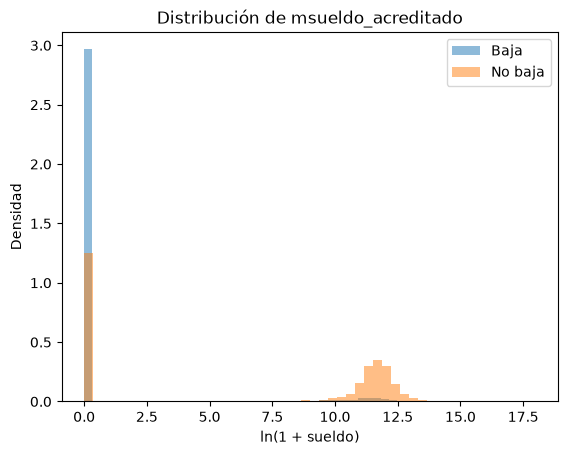

In [140]:

baja = df_resumen.loc[
    df_resumen["mes_baja"].notna(),
    "msueldo_acreditado"
].dropna()

no_baja = df_resumen.loc[
    df_resumen["mes_baja"].isna(),
    "msueldo_acreditado"
].dropna()

plt.hist(np.log1p(baja), bins=50, alpha=0.5, density=True, label="Baja")
plt.hist(np.log1p(no_baja), bins=50, alpha=0.5, density=True, label="No baja")

plt.xlabel("ln(1 + sueldo)")
plt.ylabel("Densidad")
plt.title("Distribución de msueldo_acreditado")
plt.legend()
plt.show()

## Consumo tarjetas vs baja

In [86]:
def resumen_consumo_credito_por_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_consumo_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "mtarjetas_consumo"
            ]
        ].copy()

        base_mes["mes_consumo_analisis"] = mes_consumo_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Sueldo solamente si tiene sueldo acreaditado en el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_consumo_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["consumo_1"] = base_mes['mtarjetas_consumo'] > 0
        base_mes["consumo_0"] = base_mes['mtarjetas_consumo'] <=0

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_consumo_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_consumo_1=("consumo_1", "sum"),
                clientes_consumo_0=("consumo_0", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_consumo_1"] = (
        resultado["clientes_consumo_1"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_consumo_0"] = (
        resultado["clientes_consumo_0"]
        / resultado["clientes_total"]
    )

    return resultado

In [87]:
resumen_credito = resumen_consumo_credito_por_mes_baja(df_resumen)
resumen_credito

,mes_consumo_analisis,foto_mes_actividad,grupo,clientes_total,clientes_consumo_1,clientes_consumo_0,proporcion_consumo_1,proporcion_consumo_0
0,202104,202103,baja,1013,524,489,0.517275,0.482725
1,202104,202103,no_baja,161887,151288,10599,0.934528,0.065472
2,202105,202104,baja,955,482,473,0.504712,0.495288
3,202105,202104,no_baja,162329,151736,10593,0.934744,0.065256
4,202106,202105,baja,1138,514,624,0.451670,0.548330
5,202106,202105,no_baja,162630,152141,10489,0.935504,0.064496
6,202107,202106,baja,871,487,384,0.559127,0.440873
7,202107,202106,no_baja,163243,152918,10325,0.936751,0.063249
8,202108,202107,baja,1103,527,576,0.477788,0.522212
9,202108,202107,no_baja,163245,153220,10025,0.938589,0.061411


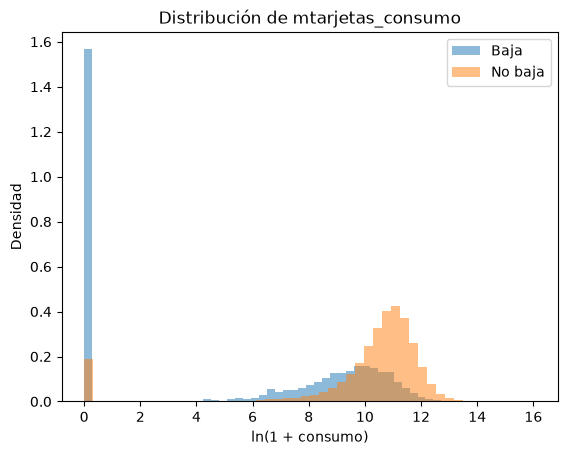

In [139]:
baja = df_resumen.loc[
    df_resumen["mes_baja"].notna(),
    "mtarjetas_consumo"
].dropna()

no_baja = df_resumen.loc[
    df_resumen["mes_baja"].isna(),
    "mtarjetas_consumo"
].dropna()

plt.hist(np.log1p(baja), bins=50, alpha=0.5, density=True, label="Baja")
plt.hist(np.log1p(no_baja), bins=50, alpha=0.5, density=True, label="No baja")

plt.xlabel("ln(1 + consumo)")
plt.ylabel("Densidad")
plt.title("Distribución de mtarjetas_consumo")
plt.legend()
plt.show()

## Saldo cuenta vs baja


In [107]:
def resumen_saldo_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_baja_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "mcuentas_saldo"
            ]
        ].copy()

        base_mes["mes_baja_analisis"] = mes_baja_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Sueldo solamente si tiene sueldo acreaditado en el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_baja_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["saldo_neg"] = base_mes['mcuentas_saldo'] < 0
        base_mes["saldo_0"] = base_mes['mcuentas_saldo'] ==0
        base_mes["saldo_pos"] = base_mes['mcuentas_saldo'] >0

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_baja_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_saldo_neg=("saldo_neg", "sum"),
                clientes_saldo_0=("saldo_0", "sum"),
                clientes_saldo_pos=("saldo_pos", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_saldo_neg"] = (
        resultado["clientes_saldo_neg"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_saldo_0"] = (
        resultado["clientes_saldo_0"]
        / resultado["clientes_total"]
    )
    resultado["proporcion_saldo_pos"] = (
        resultado["clientes_saldo_pos"]
        / resultado["clientes_total"]
    )
    resultado['suma_prop']=resultado["proporcion_saldo_pos"] + resultado["proporcion_saldo_0"]+ resultado["proporcion_saldo_neg"]
    return resultado

In [108]:
resumen_saldo = resumen_saldo_mes_baja(df_resumen)
resumen_saldo

,mes_baja_analisis,foto_mes_actividad,grupo,clientes_total,clientes_saldo_neg,clientes_saldo_0,clientes_saldo_pos,proporcion_saldo_neg,proporcion_saldo_0,proporcion_saldo_pos,suma_prop
0,202104,202103,baja,1013,596,25,392,0.588351,0.024679,0.386969,1.0
1,202104,202103,no_baja,161887,32669,1044,128174,0.201801,0.006449,0.791750,1.0
2,202105,202104,baja,955,570,27,358,0.596859,0.028272,0.374869,1.0
3,202105,202104,no_baja,162329,32686,992,128651,0.201357,0.006111,0.792532,1.0
4,202106,202105,baja,1138,705,24,409,0.619508,0.021090,0.359402,1.0
5,202106,202105,no_baja,162630,32727,970,128933,0.201236,0.005964,0.792800,1.0
6,202107,202106,baja,871,526,27,318,0.603904,0.030999,0.365098,1.0
7,202107,202106,no_baja,163243,27758,929,134556,0.170041,0.005691,0.824268,1.0
8,202108,202107,baja,1103,651,40,412,0.590209,0.036265,0.373527,1.0
9,202108,202107,no_baja,163245,29310,919,133016,0.179546,0.005630,0.814824,1.0


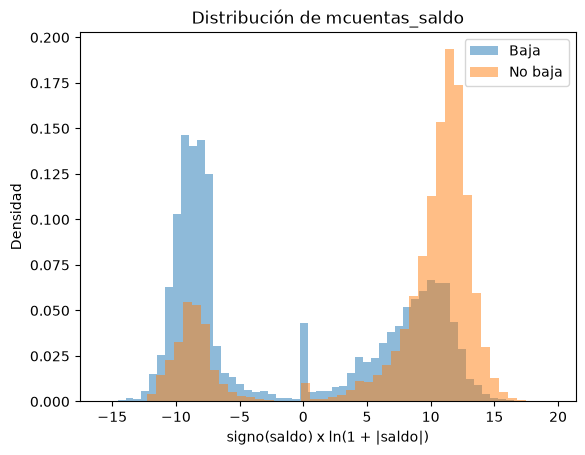

In [134]:
baja = df_resumen.loc[
    df_resumen["mes_baja"].notna(),
    "mcuentas_saldo"
].dropna()

no_baja = df_resumen.loc[
    df_resumen["mes_baja"].isna(),
    "mcuentas_saldo"
].dropna()
def log_con_signo(x):
    return np.sign(x) * np.log1p(np.abs(x))
plt.hist(log_con_signo(baja), bins=50, alpha=0.5, density=True, label="Baja")
plt.hist(log_con_signo(no_baja), bins=50, alpha=0.5, density=True, label="No baja")

plt.xlabel("signo(saldo) x ln(1 + |saldo|)")
plt.ylabel("Densidad")
plt.title("Distribución de mcuentas_saldo")
plt.legend()
plt.show()

## Transacciones HB vs Baja

In [110]:
def resumen_hb_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_baja_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "chomebanking_transacciones"
            ]
        ].copy()

        base_mes["mes_baja_analisis"] = mes_baja_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Sueldo solamente si tiene sueldo acreaditado en el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_baja_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["uso_hb"] = base_mes['chomebanking_transacciones'] >0
        base_mes["no_uso_hb"] = base_mes['chomebanking_transacciones'] <=0

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_baja_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_hb=("uso_hb", "sum"),
                clientes_no_hb=("no_uso_hb", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_no_hb"] = (
        resultado["clientes_no_hb"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_hb"] = (
        resultado["clientes_hb"]
        / resultado["clientes_total"]
    )

    resultado['suma_prop']=resultado["proporcion_no_hb"] + resultado["proporcion_hb"]
    return resultado

In [111]:
resumen_hb = resumen_hb_mes_baja(df_resumen)
resumen_hb

,mes_baja_analisis,foto_mes_actividad,grupo,clientes_total,clientes_hb,clientes_no_hb,proporcion_no_hb,proporcion_hb,suma_prop
0,202104,202103,baja,1013,558,455,0.449161,0.550839,1.0
1,202104,202103,no_baja,161887,136746,25141,0.155300,0.844700,1.0
2,202105,202104,baja,955,536,419,0.438743,0.561257,1.0
3,202105,202104,no_baja,162329,136541,25788,0.158863,0.841137,1.0
4,202106,202105,baja,1138,579,559,0.491213,0.508787,1.0
5,202106,202105,no_baja,162630,137472,25158,0.154695,0.845305,1.0
6,202107,202106,baja,871,553,318,0.365098,0.634902,1.0
7,202107,202106,no_baja,163243,137081,26162,0.160264,0.839736,1.0
8,202108,202107,baja,1103,613,490,0.444243,0.555757,1.0
9,202108,202107,no_baja,163245,138153,25092,0.153708,0.846292,1.0


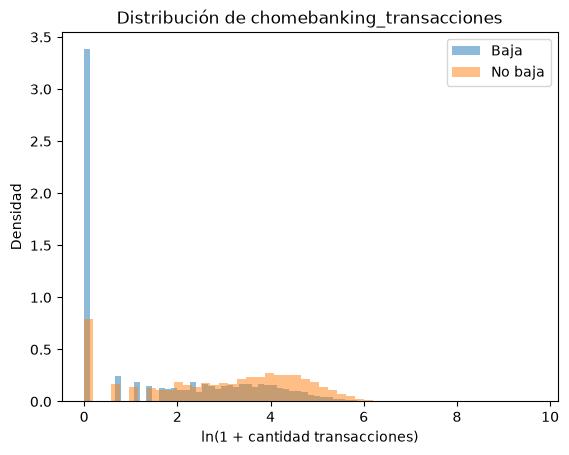

In [138]:
baja = df_resumen.loc[
    df_resumen["mes_baja"].notna(),
    "chomebanking_transacciones"
].dropna()

no_baja = df_resumen.loc[
    df_resumen["mes_baja"].isna(),
    "chomebanking_transacciones"
].dropna()

plt.hist(np.log1p(baja), bins=50, alpha=0.5, density=True, label="Baja")
plt.hist(np.log1p(no_baja), bins=50, alpha=0.5, density=True, label="No baja")

plt.xlabel("ln(1 + cantidad transacciones)")
plt.ylabel("Densidad")
plt.title("Distribución de chomebanking_transacciones")
plt.legend()
plt.show()

## Movimientos voluntarios en cuentas vs Bajas

In [112]:
def resumen_actividad_voluntaria_mes_baja(df_perfil):

    meses = sorted(df_perfil["foto_mes"].dropna().unique())
    resultados = []

    for foto_mes_actividad, mes_baja_analisis in zip(
        meses[:-1],
        meses[1:]
    ):
        # Clientes presentes durante el mes anterior a la baja
        base_mes = df_perfil.loc[
            df_perfil["foto_mes"].eq(foto_mes_actividad),
            [
                "numero_de_cliente",
                "mes_baja",
                "ctrx_quarter"
            ]
        ].copy()

        base_mes["mes_baja_analisis"] = mes_baja_analisis
        base_mes["foto_mes_actividad"] = foto_mes_actividad

        # Sueldo solamente si tiene sueldo acreaditado en el mes analizado
        base_mes["grupo"] = np.where(
            base_mes["mes_baja"].eq(mes_baja_analisis).fillna(False),
            "baja",
            "no_baja"
        )

        base_mes["actividad_voluntaria"] = base_mes['ctrx_quarter'] >0
        base_mes["sin_actividad_voluntaria"] = base_mes['ctrx_quarter'] <=0

        resumen_mes = (
            base_mes
            .groupby(
                [
                    "mes_baja_analisis",
                    "foto_mes_actividad",
                    "grupo"
                ],
                as_index=False
            )
            .agg(
                clientes_total=("numero_de_cliente", "nunique"),
                clientes_actividad_voluntaria=("actividad_voluntaria", "sum"),
                clientes_no_actividad_voluntaria=("sin_actividad_voluntaria", "sum")
            )
        )

        resultados.append(resumen_mes)

    resultado = pd.concat(resultados, ignore_index=True)

    resultado["proporcion_no_actividad_voluntaria"] = (
        resultado["clientes_no_actividad_voluntaria"]
        / resultado["clientes_total"]
    )

    resultado["proporcion_actividad_voluntaria"] = (
        resultado["clientes_actividad_voluntaria"]
        / resultado["clientes_total"]
    )

    resultado['suma_prop']=resultado["proporcion_no_actividad_voluntaria"] + resultado["proporcion_actividad_voluntaria"]
    return resultado

In [113]:
resumen_av = resumen_actividad_voluntaria_mes_baja(df_resumen)
resumen_av

,mes_baja_analisis,foto_mes_actividad,grupo,clientes_total,clientes_actividad_voluntaria,clientes_no_actividad_voluntaria,proporcion_no_actividad_voluntaria,proporcion_actividad_voluntaria,suma_prop
0,202104,202103,baja,1013,879,134,0.132280,0.867720,1.0
1,202104,202103,no_baja,161887,160287,1600,0.009883,0.990117,1.0
2,202105,202104,baja,955,842,113,0.118325,0.881675,1.0
3,202105,202104,no_baja,162329,160758,1571,0.009678,0.990322,1.0
4,202106,202105,baja,1138,980,158,0.138840,0.861160,1.0
5,202106,202105,no_baja,162630,161090,1540,0.009469,0.990531,1.0
6,202107,202106,baja,871,795,76,0.087256,0.912744,1.0
7,202107,202106,no_baja,163243,161673,1570,0.009618,0.990382,1.0
8,202108,202107,baja,1103,959,144,0.130553,0.869447,1.0
9,202108,202107,no_baja,163245,161659,1586,0.009715,0.990285,1.0


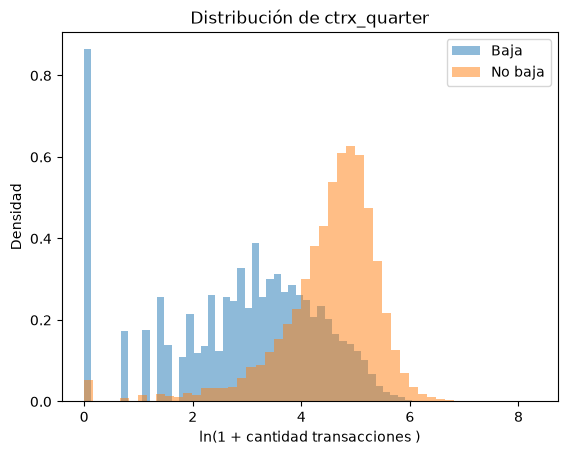

In [142]:
baja = df_resumen.loc[
    df_resumen["mes_baja"].notna(),
    "ctrx_quarter"
].dropna()

no_baja = df_resumen.loc[
    df_resumen["mes_baja"].isna(),
    "ctrx_quarter"
].dropna()

plt.hist(np.log1p(baja), bins=50, alpha=0.5, density=True, label="Baja")
plt.hist(np.log1p(no_baja), bins=50, alpha=0.5, density=True, label="No baja")

plt.xlabel("ln(1 + cantidad transacciones )")
plt.ylabel("Densidad")
plt.title("Distribución de ctrx_quarter")
plt.legend()
plt.show()

## diagramas de BEN donde muestre las proporciones de BAJA no BAJA para todas estas categorias, probablemente todas tengan un intercepto con ciertas cantidades q satisfacen todas al mismo tiempo.
## Napoleeon campaign in russia kinda plot

## * podemos plantear en, "voy a tratar de convencerte que hay valor que se puede erxtraer" 
## y voy a tratar de acotar ese valor con los 2 escenarios mas simples y opuestos entre si
## Techo de valor a extraer -> campaña perfecta
## podemos plantear en Piso de valor a extraer-> en la superposicion de todos los "diagramas de ben" q tenemos para los q se dieron alguna vez de baja o usar algun otro "modelo" extrmadamente poco sofisticado como baseline 

## ** Voy a tratar de convencerte de ¿2? cosas.
    1-> existe un gap enorme entre la mejor campaña posible, y lo que actualmente estamos haciendo. 
    2-> hay perfiles completamente distintos en las personas que abandonan el banco, sin pretender hacer el trabajo de marketing ni de darle lineamientos a marketing
    el foco en esto es dejar claro que hay informacion con la que trabajar para preveer tratamientos diferentes. 